# 🎮💹 NOTEBOOK DE VELJKO L'ANALYSTE (et pro gamer)	🎮💹

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le 

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

Important des différents package

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
# =============================================================================
# ÉTAPE 1 : PRÉPARATION ET IMPORTATION DES DONNÉES STATIONNARISÉES
# =============================================================================

# 1. Définition du chemin d'accès au fichier (le 'r' devant sert à ignorer les antislashs Windows)
path_parquet_file = "/Users/timeogrienti/economic_research/DATALAKE/PARQUET_FOLDER/main_detrended.parquet"

# 2. Chargement du fichier Parquet dans un DataFrame Pandas
# Le format Parquet est privilégié pour sa rapidité et la conservation des types de données
df = pd.read_parquet(path_parquet_file)

# 3. Sélection des variables pour l'analyse économétrique
# Note : Nous privilégions les versions stationnarisées (suffixe _stat) pour éviter 
# le risque de régression spurieuse (fictive) dû à des tendances non-stationnaires.
df_detrended = df[[
    'year',                  # Variable temporelle pour le contrôle des chocs de période
    'gdp_nominal_stat',      # Variable dépendante (Y) : Croissance du PIB nominal
    'expected_inflation',    # Contrôle : Anticipations des agents (clé pour la courbe de Phillips)
    'taux_changes_stat',     # Contrôle : Canal de transmission externe (Compétitivité-prix)
    'cpi_stat',              # Variable dépendante alternative : Stabilité des prix
    'taux_directeur',        # Variable d'intérêt (X) : Instrument de politique monétaire
    'export_stat',           # Contrôle : Demande extérieure nette
    'import_stat_stat',      # Contrôle : Absorption de la demande domestique
    'yield_perpetual_stat',  # Contrôle : Taux longs (Anticipations de marché et coût du capital)
    'oil_price_stat',        # Contrôle : Chocs d'offre exogènes (Poussée inflationniste)
    'gdp_cycle',             # Indicateur conjoncturel (Écarts à court terme)
    'gdp_trend_stat_stat',   # Contrôle de la croissance potentielle de long terme
    'output_gap'             # Mesure de la pression sur les capacités de production
]].copy()

In [4]:
# 1. Régime "Gold Standard" : on marque d'un '1' toutes les années jusqu'à 1932 inclus
df_detrended['d_gold'] = np.where(df_detrended['year'] <= 1932, 1, 0)

# 2. Régime "Bretton Woods" : on marque d'un '1' l'intervalle 1944-1971
# Note l'usage du '&' pour combiner les deux bornes temporelles
df_detrended['d_woods'] = np.where((df_detrended['year'] >= 1944) & (df_detrended['year'] <= 1971), 1, 0)

# 3. Régime "Floating" (Changes flottants) : on marque d'un '1' tout ce qui suit 1971
df_detrended['d_floating'] = np.where(df_detrended['year'] >= 1972, 1, 0)

In [5]:
# --- CRÉATION DES VARIABLES D'INTERACTION (EFFICACITÉ PAR RÉGIME) ---

# On multiplie le taux directeur par la dummy 'Gold Standard'
# Résultat : la valeur du taux si year <= 1932, sinon 0.
df_detrended['gold_int'] = df_detrended['taux_directeur'] * df_detrended['d_gold']

# On multiplie le taux directeur par la dummy 'Bretton Woods'
# Résultat : la valeur du taux uniquement entre 1944 et 1971, sinon 0.
df_detrended['woods_int'] = df_detrended['taux_directeur'] * df_detrended['d_woods']

# On multiplie le taux directeur par la dummy 'Floating'
# Résultat : la valeur du taux uniquement pour la période après 1971, sinon 0.
df_detrended['floating_int'] = df_detrended['taux_directeur'] * df_detrended['d_floating']

In [6]:
# =============================================================================
# ÉTAPE 2 : SPÉCIFICATION ET ESTIMATION DES MODÈLES ÉCONOMÉTRIQUES
# =============================================================================

# 1. Définition des variables dépendantes (Y)
# Nous testons l'impact de la politique monétaire sur le "Triangle d'Or" de l'économie
Y_gdp = df_detrended['gdp_nominal_stat']       # Objectif 1 : Dynamique de l'activité réelle (Croissance)
Y_inflation = df_detrended['cpi_stat']         # Objectif 2 : Maîtrise de l'inflation (Stabilité interne)
Y_change = df_detrended['taux_changes_stat']   # Objectif 3 : Équilibre extérieur (Stabilité de la monnaie)

# 2. Construction de la matrice des variables explicatives (X)
# Nous isolons l'effet du taux directeur via des variables d'interaction spécifiques aux régimes.
# Cela permet de comparer directement l'efficacité monétaire entre l'Étalon-Or, Bretton Woods et le Change Flottant.
X = df_detrended[['gold_int', 'woods_int', 'floating_int']]

# 3. Ajout de la constante (Intercept)
# Crucial : Sans constante, le modèle force la droite de régression à passer par l'origine, 
# ce qui biaiserait artificiellement les coefficients de nos régimes.
X = sm.add_constant(X)

# 4. Estimation des modèles par les Moindres Carrés Ordinaires (OLS)
# L'option missing='drop' assure une gestion rigoureuse des discontinuités historiques.
model_gdp_1  = sm.OLS(Y_gdp, X, missing='drop').fit()
model_inf_1  = sm.OLS(Y_inflation, X, missing='drop').fit()
model_exch_1 = sm.OLS(Y_change, X, missing='drop').fit()

# =============================================================================
# ÉTAPE 3 : ÉDITION DES RÉSULTATS (DIAGNOSTIC INITIAL)
# =============================================================================

#Affichage des résumés statistiques pour analyse des R-squared, P-values et tests de diagnostic (JB, DW)
print("=== MODÈLE 1 : IMPACT SUR LE PIB NOMINAL ===")
print(model_gdp_1.summary())

print("\n=== MODÈLE 2 : IMPACT SUR L'INFLATION (CPI) ===")
print(model_inf_1.summary())

print("\n=== MODÈLE 3 : IMPACT SUR LE TAUX DE CHANGE ===")
print(model_exch_1.summary())

=== MODÈLE 1 : IMPACT SUR LE PIB NOMINAL ===
                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     26.02
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.49e-12
Time:                        08:35:32   Log-Likelihood:                 217.21
No. Observations:                 105   AIC:                            -426.4
Df Residuals:                     101   BIC:                            -415.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
con

**<span style="color:yellow"> On realise des pearson test afin de savoir si les residus de chacune de nos regressions sont corrêlés (explication du pourquoi faire cela dans l'analyse ci dessous**

In [7]:
# Au sein de la partie précédente on suppose que les résidus entre les différentes périodes ne sont pas corrêlés ce qui est empiriquement fortement peu probable.
# On prouve ci dessous que les résidus des 3 régressions sont corrêlés. 

from scipy.stats import pearsonr
e_gdp   = model_gdp_1.resid
e_exch  = model_exch_1.resid
e_inf   = model_inf_1.resid

# Listes des corr avec pearson
corr_gdp_exch, pval_gdp_exch = pearsonr(e_gdp, e_exch)
corr_gdp_inf,  pval_gdp_inf  = pearsonr(e_gdp, e_inf)
corr_exch_inf, pval_exch_inf = pearsonr(e_exch, e_inf)

print("GDP et ex rate : corr =", corr_gdp_exch, ", p =", pval_gdp_exch)
print("GDP et pit : corr =", corr_gdp_inf, ", p =", pval_gdp_inf)
print("ex rate et pit : corr =", corr_exch_inf, ", p =", pval_exch_inf)

# ON peut analyser ci dessous les resultats 

GDP et ex rate : corr = 0.048880873296936474 , p = 0.6204728529258521
GDP et pit : corr = 0.7125490807409403 , p = 1.535944841599208e-17
ex rate et pit : corr = -0.19480878114554825 , p = 0.04643438297801346


#### <span style="color:yellow"> **On analyse ci dessous les résultats du pearson test de la corrélation des résidus des trois regressions** 
Sous l'hypothèse nulle : 

$$
H_0 : \operatorname{corr}(\varepsilon_a, \varepsilon_b) = 0, \quad H_1 : \operatorname{corr}(\varepsilon_a, \varepsilon_b) \neq 0, \quad
\text{avec } a,b \in \{ Y_{\text{GDP}}, Y_{\text{ExchangeRate}}, Y_{\text{Inflation}} \}
$$

Les résidus de la régression sur l'inflation et sur le PIB sont significativement fortement corrêlés. Ainsi il serait plus rigoureux de réaliser une analyse MANOVA (multivariate analysis of variance) pour éviter d'éstimer à tord au sein des régression la redondance des résidus au sein des régressions. Admettons par exemple que les résidus entre deux régressions soient fortement corrêlés comme dans notre cas, il est fortement probable que lorsque l'on éstime l'effet des taux sur chacune des deux variables nous estimions à deux reprise la part d'erreur corrêlés entre les deux modèles, tandis que nous arriverions à omettre cet effet en fusionnant les deux régressions en une. Gràce à la MANOVA nous pourrons donc ne pas sur ou sous estimer les erreurs standards au sein des test de significativités. 

#### **MANOVA CI DESSOUS :** 



### <span style="color:yellow"> **Explication du principe de la MANOVA et ces composants**

Une Manova ou multivariate variance analysis est une anova mais réalisée sur plusieurs variables dépendantes en même temps. Au lieu de tester si les groupes diffèrent sur une seule mesure, on test s'ils diffèrent sur une combinaison de plusieurs mesures en tenant compte des corélations entre elles. 

Ici les groupes sont les différents groupes, et on veut savoir si l'effet des taux sur l'économie (PIB,inflation) diffère entre les différents groupes. 

Ses composantes sont : 

- Wilks' lambda : mesure la proportion de variance non éxpliqué par les groupes. Quel part de comportement du PIB et de l'inflation est non éxpliqué par les régimes ? 
         
- Pillai's trace : Combien de variance de l'inflation et du PIB est éxpliqué à travers le régime X ? (inverse de la question précédente)
 
- Hotelling-Lawley trace : A quelle point les fluctuations entre les régimes dépassents les fluctuations normales ? 
    
- Roy's greatest root : Dans la direction ou les régimes diffèrent le plus ya t-il un effet fort ?

En gros le plus important est la "Pillai's trace" car elle nous permet de mesurer l'intensité des pouvoir prédictif sur la variance de l'économie des différents régimes : 

gold standard : 3,59% et non significatif
Bretton wood : 14,73% significatif
floating rate : 28,83% très significatif


In [8]:
from statsmodels.multivariate.manova import MANOVA

df_manova = pd.concat([df_detrended[['gdp_nominal_stat', 'cpi_stat', 'taux_changes_stat']], X], axis=1)
manova = MANOVA.from_formula('gdp_nominal_stat + cpi_stat ~ gold_int + woods_int + floating_int', data=df_manova)

print(manova.mv_test())

                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.7334 2.0000 100.0000 18.1774 0.0000
         Pillai's trace 0.2666 2.0000 100.0000 18.1774 0.0000
 Hotelling-Lawley trace 0.3635 2.0000 100.0000 18.1774 0.0000
    Roy's greatest root 0.3635 2.0000 100.0000 18.1774 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
        gold_int        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9631 2.0000 100.0000  1.9179 0.1523
         Pillai's trace 0.0369 2.0000 100.0000  1.9179 0.1523
 Hotelling-Lawley trace 0.

#### <span style="color:yellow">**ANALYSE RESULTAT MANOVA**
Ces resultats sont plutot concluants : 
gold_int :  pas d’effet significatif des taux sur les variables d'interets durant la période gold standard.
woods_int : effet significatif à 1,2% des taux d'interet sur les variables d'interet durant la periode bretton wood.
floating_int : effet extremement significatif à mois de 0.000% des taux d'interet sur les variables d'interet durant la periode floating rate. 

Ceci prend sens sur le plan macroéconomique étant donnée qu'il permettent de mettre en avant que l'effet des taux augmente lorsque la politique monétaire s'éloigne de la gestion de la politique monétaire à travers l'or. 

la MANOVA nous permet de valider un postulat super important pour notre étude étant qu'au dela de l'effet plus ou moins bon des différentes politiques monétaires sur la minimisation du cout social, la politique monétaire entraine une variation dans l'effet de transmissiond des taux sur les agrégats économique. 

**<span style="color:yellow">CONCLUSION D'ANALYSE MANOVA : LE REGIME À DONC BIEN UN REEL IMPACT SUR LA MANIERE DONT LES TAUX IMPACTENT LES AGREGATS ÉTUDIÉS**

<span style="color:red">**Interprétation** 

Pour l'instant, relation statistiquement significative durant les périodes de Breton Woods et floating rates pour le gdp_nominal et le cpi. Cependant pour les taux de changes c'est une catastrophe. Durbin-Watson stipule une autocorrélation positive et Jarque-Bera nous dit que c'est loin d'être une loi normale. Forcèment le R carré est très petit. Je compte donc ajouter toutes les autres variables en contrôle.



In [9]:
# =============================================================================
# ÉTAPE 4 : MODÉLISATION AVEC VARIABLES DE CONTRÔLE (MULTIVARIÉE)
# =============================================================================

# 1. Sélection de la matrice augmentée (C)
# Nous intégrons des variables de contrôle pour isoler l'effet "net" de la politique monétaire.
# Cela permet d'éviter le biais de variable omise.
C = df_detrended[[
    # Variables d'intérêt principal : captures de l'effet taux selon le régime monétaire
    'gold_int', 'woods_int', 'floating_int', 

    # Contrôles de la balance commerciale : impact du secteur extérieur sur le PIB et les prix
    'export_stat', 'import_stat_stat',       

    # Contrôles financiers et d'offre :
    'yield_perpetual_stat',                  # Capture les anticipations de long terme du marché
    'oil_price_stat',                        # Capture les chocs d'offre exogènes mondiaux

    # Contrôles de structure économique :
    'gdp_cycle', 'gdp_trend_stat_stat',      # Dissociation de la tendance et du cycle
    'output_gap',                            # Mesure de la tension sur l'appareil productif
    'expected_inflation'                     # Prise en compte de l'inertie des prix (anticipations)
]]

# 2. Ajout de la constante (Intercept)
# Essentiel pour capturer le niveau de base de la variable dépendante non expliqué par les contrôles
C = sm.add_constant(C)

# 3. Estimation des modèles OLS multivariés
# Ces modèles permettent de tester la robustesse de nos interactions de taux 
# lorsqu'elles sont confrontées à d'autres déterminants majeurs de l'économie.
model_gdp_2   = sm.OLS(Y_gdp, C, missing='drop').fit()
model_inf_2   = sm.OLS(Y_inflation, C, missing='drop').fit()
model_exch_2  = sm.OLS(Y_change, C, missing='drop').fit()

# =============================================================================
# ÉTAPE 5 : ANALYSE DES RÉSULTATS ET DIAGNOSTIC DE COLINÉARITÉ
# =============================================================================

# Note : Il faudra surveiller le "Condition Number" dans ces summaries pour 
# détecter une éventuelle multicolinéarité entre le PIB, le Cycle et l'Output Gap.
print("=== MODÈLE PIB (AVEC CONTRÔLES) ===")
print(model_gdp_2.summary())

print("\n=== MODÈLE INFLATION (AVEC CONTRÔLES) ===")
print(model_inf_2.summary())

print("\n=== MODÈLE CHANGE (AVEC CONTRÔLES) ===")
print(model_exch_2.summary())

=== MODÈLE PIB (AVEC CONTRÔLES) ===
                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     23.48
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.98e-22
Time:                        08:35:32   Log-Likelihood:                 256.91
No. Observations:                 105   AIC:                            -489.8
Df Residuals:                      93   BIC:                            -458.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

<span style="color:red">**Note** 

Avec l'ajout des variables de contrôles ça devient beaucoup mieux. les deux R carré grimpent, les relations significatives pour le gdp_nominal et les taux de changes ne changent pas. En revanche pour le cpi toutes les relations significatives disparaîssent. 

l'output gap et les imports ont un coef extrêmement petit et ne sont pas significatif, l'output gap, dans la heatmap, nous montre qu'il n'est pas vraiment corrélé à quoique ce soit. 
Pour le gdp, normalité sous Jarque-Bera mais autocorrélation positive, pas mal d'autres variables significatives
Pour les deux autres, bidouiller l'expression peut-être en mettant des spécifiations serait intéréssant. Cond. No énorme par la suite j'enlève l'ouput_Gap et le gdp_cycle qui cause ce chiffre énorme.

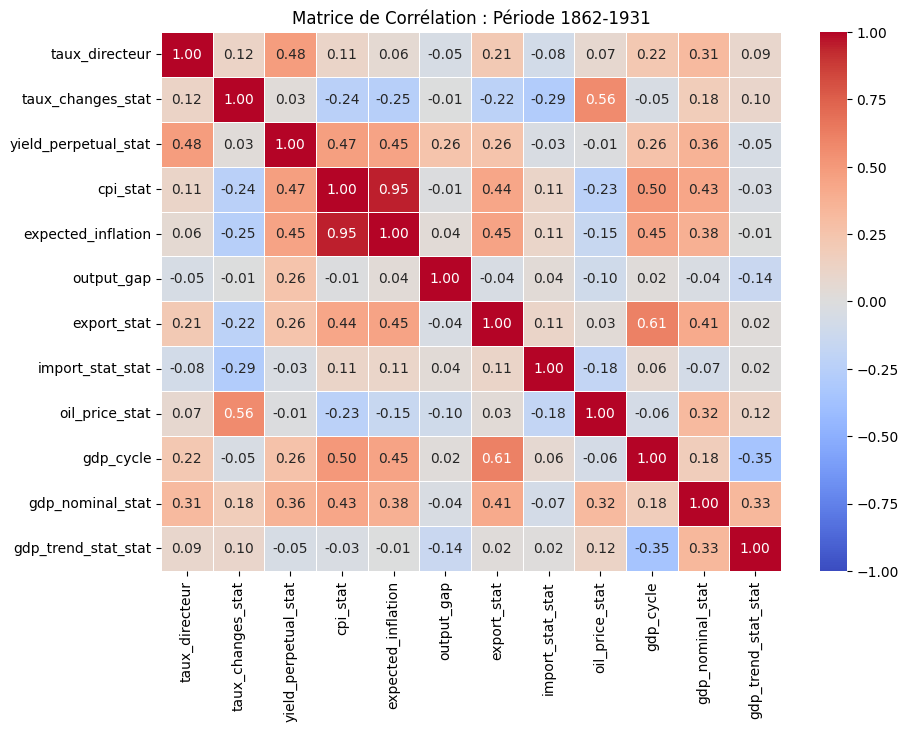

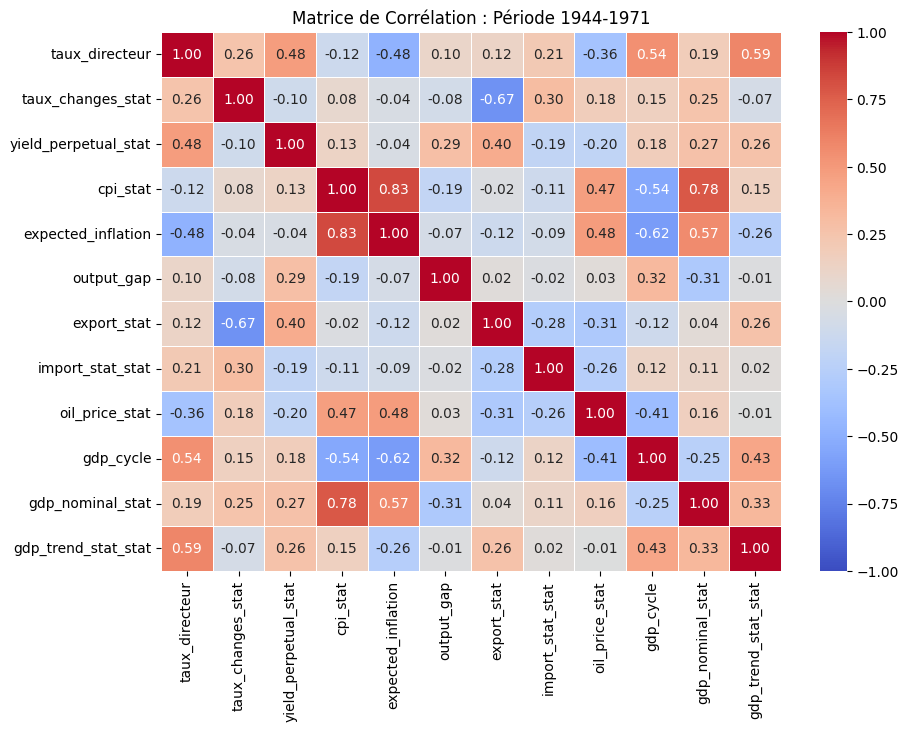

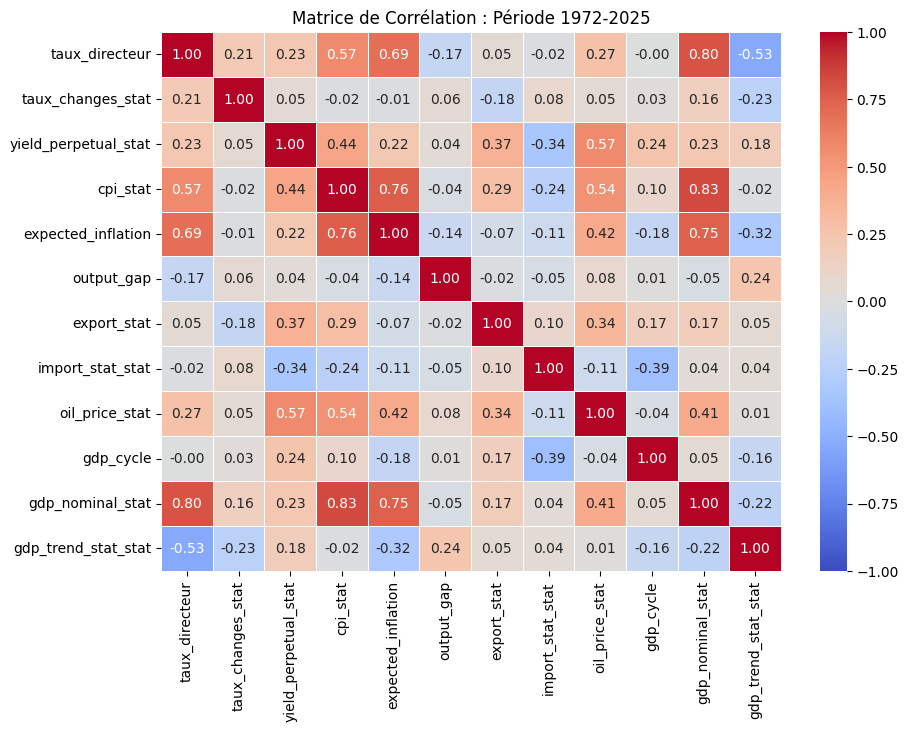

In [10]:
import sys

sys.path.append("../dorian_code")

from outils_eda import *

cols_selection = ['year',
    'taux_directeur', 
    'taux_changes_stat', 
    'yield_perpetual_stat', 
    'cpi_stat', 
    'expected_inflation',
    'output_gap',
    'export_stat',
    'import_stat_stat', 
    'oil_price_stat',
    'gdp_cycle', 
    'gdp_nominal_stat', 
    'gdp_trend_stat_stat'
]

corr_matrix(df_detrended[cols_selection])

In [11]:
#---Les variables output_gap et import_stat, export ont été retirée car très corrélée et output_gap et gpd_trend_stat_stat trop peu corrélé---
#Le coefficient de la variable export était négative, Ce qui est contre-intuitif. 
C_gdp = df_detrended[[
    'gold_int', 'woods_int', 'floating_int', # Interactions (notre intérêt principal)                           # Secteur extérieur
    'yield_perpetual_stat',                  # Taux longs (marché obligataire)
    'oil_price_stat',                        # Choc d'offre (Pétrole)
    'gdp_trend_stat_stat',
    'expected_inflation'                             # Écart de production (mesure de surchauffe)                 
]]

# Ajout de la constante pour l'intercepte de la régression
C_gdp = sm.add_constant(C_gdp)

# Estimation des modèles OLS pour chaque variable cible
# On observe l'impact "toutes choses égales par ailleurs"
model_gdp_3 = sm.OLS(Y_gdp, C_gdp, missing='drop').fit()
#model_inf_3 = sm.OLS(Y_inflation, C2, missing='drop').fit()
#model_exch_3 = sm.OLS(Y_change, C2, missing='drop').fit()

# Affichage du résumé pour les taux de change
print(model_gdp_3.summary())

C_inf = df_detrended[[
    'gold_int', 'woods_int', 'floating_int', # Interactions (notre intérêt principal)
    'export_stat', 'import_stat_stat',       # Secteur extérieur
    'yield_perpetual_stat',                  # Taux longs (marché obligataire)
    'oil_price_stat',                        # Choc d'offre (Pétrole)
    'gdp_trend_stat_stat'     # Composantes du PIB                         # Écart de production (mesure de surchauffe)                     # Anticipations des agents
]]

C_inf = sm.add_constant(C_inf)


model_inf_3 = sm.OLS(Y_inflation, C_inf, missing='drop').fit()
print(model_inf_3.summary())

C_exch = df_detrended[[
    'gold_int', 'woods_int', 'floating_int', # Interactions (notre intérêt principal)
    'export_stat', 'import_stat_stat',       # Secteur extérieur
    'yield_perpetual_stat',                  # Taux longs (marché obligataire)
    'oil_price_stat',                        # Choc d'offre (Pétrole)
    'gdp_trend_stat_stat',      # Composantes du PIB                            # Écart de production (mesure de surchauffe)
    'expected_inflation'                     # Anticipations des agents
]]
C_exch = sm.add_constant(C_exch)

model_exch_3 = sm.OLS(Y_change, C_exch, missing='drop').fit()

print("=== RÉSULTATS MODÈLE 3 ===")
print(model_exch_3.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     35.85
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           3.02e-24
Time:                        08:35:33   Log-Likelihood:                 254.20
No. Observations:                 105   AIC:                            -492.4
Df Residuals:                      97   BIC:                            -471.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0243 

<span style="color:red">**Note**

Comme mentionné plus haut, j'ai envelvé output_gap et gdp_cycle parce que la Cond. No. réduit énormément.

Pour le gdp, j'ai enlevé l'import car coef très petit et non significatif et j'ai enlevé l'export car le coef était négatif ce que je trouve contre-intuitif.

Pour le cpi, j'ai enlevé expected_inflation car très corrélé d'après la heatmap de Dorian. 

Pour les taux de changes, rien de signifiucatif appart le oil_price et le dummy floating_rate et presque significatif. 

Sinon pour le test de la normalité, seulement le gdp tient la route et l'autocorrélation persiste. 

In [12]:
#--Erreurs robustes à l'hétéroscédasticité, je comptes faire un plot avec les erreurs--
model_robust_gdp = sm.OLS(Y_gdp, C_gdp, missing='drop').fit(cov_type='HC1')
model_robust_inf = sm.OLS(Y_inflation, C_inf, missing='drop').fit(cov_type='HC1')
model_robust_exch = sm.OLS(Y_change, C_exch, missing='drop').fit(cov_type='HC1')
print(model_robust_gdp.summary())
print(model_robust_inf.summary())
print(model_robust_exch.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     27.42
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           2.03e-20
Time:                        08:35:33   Log-Likelihood:                 254.20
No. Observations:                 105   AIC:                            -492.4
Df Residuals:                      97   BIC:                            -471.2
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0243 

<span style="color:red">**Note**

Les erreurs robustes n'ont pas changé grand-chose pour le gdp et le taux_change ce qui est déjà démontré dans l'analyse mutlivariée de Dorian.
Par contre pour le CPi, ça permet d'avoir des coefs significatifs
Je n'ai pas fait de spécification, les log ne vont pas fonctionner puisque c'est déjà stationnarisé en log, Pour les spécifications quadratiques, je n'ai pas eu l'impression dans l'analyse multivariée que c'était nécessaire (pas vraiment d'effet marginal) et les interactions je pourrais peut-être en rajouter. 

Hormis tout ça, je pourrais peut-être contrôler des périodes qui ont été indiqué par Dorian sur son graphique des points d'inflexions. 